# 02a Preprocessing — Ausschlussmasken

**PA1 ZHAW IUNR** | Bächler, Haag, Reichlin | Betreuer: Patrick Laube

Erstellt die 20 booleschen Ausschlussmasken für Szenario S2 (mittel) und
kombiniert sie zu einer einzigen Constraint-Maske.

**Szenario S2 Schwellenwerte:**
| Parameter | Wert | Quelle |
|-----------|------|--------|
| Höhe | 1500–2700 m | Dujardin et al. (2022) |
| Slope | < 35° | Swissolar (2025) |
| Aspect | 120°–240° | Kahl et al. (2019) |
| Gebäude-Puffer | 100 m | De Ferrars (2023) |
| Permafrost | Ausschluss > Klasse 3 | Swissolar (2025) |
| Mindestfläche | ≥ 10 ha | Swissolar (2025) |

**Output:** `data/processed/constraints/constraint_mask_s2.tif` (0 = ausgeschlossen, 1 = geeignet)

## 1. Setup & Imports

In [ ]:
from pathlib import Path
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask as rio_mask
from rasterio.transform import from_bounds
from rasterio.features import rasterize
from rasterio.warp import reproject
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy.ndimage import binary_dilation
from shapely.geometry import Point
import warnings, time, json, pickle
from datetime import datetime, timedelta
warnings.filterwarnings("ignore")

RAW  = Path("../data/raw")
PROC = Path("../data/processed")
for sub in ["dem", "constraints"]:
    (PROC / sub).mkdir(parents=True, exist_ok=True)

CACHE_DIR = PROC / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CRS    = "EPSG:2056"
RES    = 25
NODATA = -9999.0

print("Setup OK ✓")

Setup OK ✓
Szenario: {'elevation_min': 1500, 'elevation_max': 2700, 'slope_max': 35, 'aspect_min': 120, 'aspect_max': 240, 'building_buffer': 300, 'permafrost_exclude_above': 3}
Cache-Dir: ..\data\processed\cache


## 2. Konfiguration — Szenario S2

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SCHWELLENWERTE HIER ANPASSEN  (Szenario S2 = mittel)  ║
# ╚══════════════════════════════════════════════════════════╝

S2 = {
    "elevation_min": 1500,
    "elevation_max": 2700,
    "slope_max": 35,
    "aspect_min": 120,
    "aspect_max": 240,
    "building_buffer": 300,
    "permafrost_exclude_above": 3,
}

print(f"Szenario S2: {S2}")
print(f"Cache-Dir:   {CACHE_DIR}")

## 3. Funktionen

In [ ]:
def cache_get(key, max_age_days=7):
    """Lade gecachte Daten falls vorhanden."""
    cache_file = CACHE_DIR / f"{key}.pkl"
    if not cache_file.exists():
        return None
    age = datetime.now() - datetime.fromtimestamp(cache_file.stat().st_mtime)
    if age > timedelta(days=max_age_days):
        print(f"⚠ {key} Cache ist {age.days}d alt — neulade")
        return None
    try:
        with open(cache_file, "rb") as f:
            return pickle.load(f)
    except Exception as e:
        print(f"⚠ {key} Cache-Fehler: {e}")
        return None


def cache_set(key, data):
    """Speichere Daten als Cache."""
    try:
        cache_file = CACHE_DIR / f"{key}.pkl"
        with open(cache_file, "wb") as f:
            pickle.dump(data, f)
        print(f"✓ {key} gecacht")
    except Exception as e:
        print(f"⚠ Cache-Fehler: {e}")


def get_tlm_path():
    tlm = RAW / "tlm3d/swisstlm3d_2026-02-24_2056_5728.gpkg"
    return next(tlm.glob("*.gpkg")) if tlm.is_dir() else tlm


def clip_raster_to_gr(src_path):
    """Clip und reprojiziere Raster auf GR-Referenzgitter."""
    with rasterio.open(src_path) as src:
        gr_clip = gr_border.to_crs(src.crs) if src.crs and src.crs != CRS else gr_border
        out, out_tf = rio_mask(src, [gr_clip.geometry.iloc[0].__geo_interface__], crop=True, nodata=src.nodata or NODATA)
    dst = np.full((height, width), NODATA, dtype=np.float32)
    reproject(source=out[0], destination=dst, src_transform=out_tf, src_crs=src.crs, dst_transform=transform, dst_crs=CRS,
              resampling=Resampling.bilinear, src_nodata=src.nodata or NODATA, dst_nodata=NODATA)
    return dst


def rasterize_to_gr(gdf, burn=1):
    """Vektorisierte Geodaten auf Referenzraster rasterisieren."""
    gdf_c = gdf.to_crs(CRS)
    minx, miny, maxx, maxy = gr_border.total_bounds
    gdf_c = gdf_c.cx[minx:maxx, miny:maxy]
    if gdf_c.empty:
        return np.zeros((height, width), dtype=np.uint8)
    return rasterize([(g, burn) for g in gdf_c.geometry if g is not None and not g.is_empty],
                     out_shape=(height, width), transform=transform, fill=0, dtype=np.uint8)


def simplify_and_rasterize(gdf, tolerance=5, buffer=0):
    """Vereinfache Vektor-Geometrien und rasterisiere auf Referenzgitter."""
    gdf = gdf.to_crs(CRS).copy()
    gdf.geometry = gdf.geometry.simplify(tolerance)
    if buffer > 0:
        gdf.geometry = gdf.geometry.buffer(buffer)
    return rasterize_to_gr(gdf)


def save_mask(data, name):
    """Speichere boolesche Maske als GeoTIFF (uint8, LZ4-komprimiert)."""
    path = PROC / f"constraints/{name}.tif"
    with rasterio.open(path, "w", **{**ref_profile, "dtype": "uint8", "nodata": 255}) as dst:
        dst.write(data.astype(np.uint8), 1)


def report(name, mask, total_pixels):
    """Gib Flächen-Statistik für eine Constraint-Maske aus."""
    valid = mask.sum()
    excl = total_pixels - valid
    print(f"  {name:40s} {valid*RES*RES/1e6:>7.0f} km² ✓ | {excl*RES*RES/1e6:>7.0f} km² ✗ ({excl/total_pixels*100:.1f}%)")
    return mask


print("✓ Funktionen definiert")

GR: 100 Gemeinden | 5641×4010 Pixel @ 25m | 7105 km²


## 4. Referenzraster & Kantonsgrenze GR

In [ ]:
muni_path = RAW / "swissboundaries/swissboundaries_gemeinden.shp"
municipalities = gpd.read_file(muni_path)

canton_col = next(c for c in municipalities.columns if "KANT" in c.upper() or c.upper().startswith("KT"))
name_col = next(c for c in municipalities.columns if "NAME" in c.upper())

gr_muni = municipalities[municipalities[canton_col].astype(str).str.contains("GR", case=False, na=False)].copy()
if gr_muni.empty:
    gr_muni = municipalities[municipalities[canton_col].astype("Int64") == 18].copy()

gr_border = gr_muni.dissolve()
gr_geom = [gr_border.geometry.iloc[0].__geo_interface__]

# Referenzraster
bounds = gr_border.total_bounds
width = int(np.ceil((bounds[2] - bounds[0]) / RES))
height = int(np.ceil((bounds[3] - bounds[1]) / RES))
transform = from_bounds(bounds[0], bounds[1], bounds[0] + width * RES, bounds[1] + height * RES, width, height)
ref_profile = {"driver": "GTiff", "dtype": "float32", "crs": CRS, "transform": transform,
               "width": width, "height": height, "count": 1, "nodata": NODATA, "compress": "lz4"}

gr_mask_raster = rasterize([(gr_border.geometry.iloc[0], 1)],
                           out_shape=(height, width), transform=transform, fill=0, dtype=np.uint8)

total_px = gr_mask_raster.sum()
px2km = RES * RES / 1e6
print(f"GR: {len(gr_muni)} Gemeinden | {width}×{height} Pixel @ {RES}m | {total_px*px2km:.0f} km²")

GR: 11,368,539 Pixel = 7105 km²


## 5. DEM laden

In [4]:
print("=== DEM laden ===")
t0 = time.time()
dem_path = next((RAW / "dem").glob("*.tif"), None)
if not dem_path:
    asc_search = list((RAW / "dem").glob("**/dhm25_grid_raster.asc"))
    dem_path = asc_search[0] if asc_search else None
if not dem_path:
    raise FileNotFoundError("Kein DEM in data/raw/dem/ (weder .tif noch .asc gefunden)")

dem = clip_raster_to_gr(dem_path)
valid_dem = (dem != NODATA) & (gr_mask_raster == 1)

# Slope & Aspect via finite-difference gradient
# Methode: Horn (1981); Implementierung angelehnt an Earth Lab (Univ. Colorado)
# und numpy.gradient (https://numpy.org/doc/stable/reference/generated/numpy.gradient.html)
# vgl. auch Steger et al. (2022), HORAYZON v1.2, Geosci. Model Dev., 15, 6817–6840
dy, dx = np.gradient(np.where(valid_dem, dem, 0).astype(float), RES)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2))).astype(np.float32)
aspect = (np.degrees(np.arctan2(-dx, dy)) % 360).astype(np.float32)

for name, data in [("dem_gr_25m", dem), ("slope_gr_25m", slope), ("aspect_gr_25m", aspect)]:
    with rasterio.open(PROC / f"dem/{name}.tif", "w", **ref_profile) as dst:
        dst.write(data, 1)

print(f"DEM: {dem[valid_dem].min():.0f}–{dem[valid_dem].max():.0f} m | Slope: {slope[valid_dem].mean():.1f}° mean")
print(f"✓ {time.time() - t0:.1f}s")

=== DEM laden ===
DEM: 255–4040 m | Slope: 27.3° mean
✓ 29.6s


## 6. DEM-basierte Ausschlüsse (C01–C05)

In [5]:
print("=== C01–C05: DEM-basierte Ausschlüsse ===\n")
t0 = time.time()

masks_dem = {
    "c01_elev_min": ("Höhe ≥ 1500 m", (dem >= S2["elevation_min"]) & valid_dem),
    "c02_elev_max": ("Höhe ≤ 2700 m", (dem <= S2["elevation_max"]) & valid_dem),
    "c03_slope":    ("Slope < 35°",    (slope < S2["slope_max"]) & valid_dem),
    "c04_aspect":   ("Aspect 120–240°", (aspect >= S2["aspect_min"]) & (aspect <= S2["aspect_max"]) & valid_dem),
}

for cid, (label, condition) in masks_dem.items():
    m = condition.astype(np.uint8)
    report(f"{cid.upper()} {label}", m, total_px)
    save_mask(m, cid)
    globals()[cid] = m

pf_path = RAW / "permafrost/permafrost_2056.tif"
if pf_path.exists():
    pf = clip_raster_to_gr(pf_path)
    c05_permafrost = (valid_dem & ~((pf != NODATA) & (dem >= pf))).astype(np.uint8)
else:
    print("  ⚠ Permafrost nicht gefunden")
    c05_permafrost = valid_dem.astype(np.uint8)
report("C05 Permafrost", c05_permafrost, total_px)
save_mask(c05_permafrost, "c05_permafrost")
print(f"✓ {time.time() - t0:.1f}s")

=== C01–C05: DEM-basierte Ausschlüsse ===

  C01_ELEV_MIN Höhe ≥ 1500 m                  5739 km² ✓ |    1366 km² ✗ (19.2%)
  C02_ELEV_MAX Höhe ≤ 2700 m                  6372 km² ✓ |     733 km² ✗ (10.3%)
  C03_SLOPE Slope < 35°                       5237 km² ✓ |    1868 km² ✗ (26.3%)
  C04_ASPECT Aspect 120–240°                  2308 km² ✓ |    4797 km² ✗ (67.5%)
  C05 Permafrost                              5963 km² ✓ |    1142 km² ✗ (16.1%)
✓ 1.8s


## 7. Naturschutz-Ausschlüsse (C06–C12)

In [6]:
print("=== C06–C12: Schutzgebiete (BAFU) ===\n")
t0 = time.time()

schutz = cache_get("schutzgebiete_v2")

if schutz is None:
    print("  Lade von Dateien...")
    schutz = {}

    # --- AULAV Sublayers ---
    aulav_base = RAW / "protected_areas/schutzgebiete-aulav_2056.shp"

    # C06: Moorlandschaften (BAFU Moorlandschaftsinventar)
    moor_shp = aulav_base / "N2017_AulavMoorlandschaft_20171101.shp"
    if moor_shp.exists():
        gdf = gpd.read_file(moor_shp)
        mask = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        schutz["c06"] = mask
        report("C06 Moorlandschaften", mask, total_px)
        save_mask(mask, "c06_moorlandschaften")
    else:
        print("  ⚠ C06 Moorlandschaften: nicht gefunden")
        schutz["c06"] = np.ones((height, width), dtype=np.uint8)

    # C07: Biotope (Auen + Hochmoore + Flachmoore aus UebrigeSchutzgebiete)
    auen_shp = aulav_base / "N2017_AulavAuen_20171101.shp"
    uebrige_shp = aulav_base / "N2023_AulavUebrigeSchutzgebiete_20230701.shp"
    biotop_parts = []
    if auen_shp.exists():
        biotop_parts.append(gpd.read_file(auen_shp))
    if uebrige_shp.exists():
        uebrige = gpd.read_file(uebrige_shp)
        biotop_parts.append(uebrige[uebrige["Discrimina"].isin(["Hochmoore", "Flachmoore"])])
    if biotop_parts:
        gdf_biotop = pd.concat(biotop_parts, ignore_index=True)
        mask = ((rasterize_to_gr(gdf_biotop) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        schutz["c07"] = mask
        report(f"C07 Biotope (Auen + Hoch-/Flachmoore, {len(gdf_biotop)} Features)", mask, total_px)
        save_mask(mask, "c07_biotope")
    else:
        print("  ⚠ C07 Biotope: nicht gefunden")
        schutz["c07"] = np.ones((height, width), dtype=np.uint8)

    # C08: Vogelreservate (WildUndZugvogelReservat aus UebrigeSchutzgebiete)
    if uebrige_shp.exists():
        if "uebrige" not in locals():
            uebrige = gpd.read_file(uebrige_shp)
        gdf_vogel = uebrige[uebrige["Discrimina"] == "WildUndZugvogelReservat"]
        mask = ((rasterize_to_gr(gdf_vogel) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        schutz["c08"] = mask
        report(f"C08 Vogelreservate ({len(gdf_vogel)} Features)", mask, total_px)
        save_mask(mask, "c08_vogelreservate")
    else:
        print("  ⚠ C08 Vogelreservate: nicht gefunden")
        schutz["c08"] = np.ones((height, width), dtype=np.uint8)

    # C09: BLN (Bundesinventar Landschaften)
    bln_path = RAW / "protected_areas/bundesinventare-bln_2056.shp"
    if bln_path.exists():
        gdf = gpd.read_file(bln_path)
        mask = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        schutz["c09"] = mask
        report(f"C09 BLN ({len(gdf)} Features)", mask, total_px)
        save_mask(mask, "c09_bln")
    else:
        print("  ⚠ C09 BLN: nicht gefunden")
        schutz["c09"] = np.ones((height, width), dtype=np.uint8)

    # C10: Nationalpark (aus UebrigeSchutzgebiete)
    if uebrige_shp.exists():
        if "uebrige" not in locals():
            uebrige = gpd.read_file(uebrige_shp)
        gdf_np = uebrige[uebrige["Discrimina"] == "Nationalpark"]
        mask = ((rasterize_to_gr(gdf_np) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        schutz["c10"] = mask
        report(f"C10 Nationalpark ({len(gdf_np)} Features: {gdf_np['Name'].tolist()})", mask, total_px)
        save_mask(mask, "c10_nationalpark")
    else:
        print("  ⚠ C10 Nationalpark: nicht gefunden")
        schutz["c10"] = np.ones((height, width), dtype=np.uint8)

    # C11: Biosphärenreservat
    bio_path = RAW / "protected_areas/schutzgebiete-biosphaerenreservate_2056.shp"
    if bio_path.exists():
        gdf = gpd.read_file(bio_path)
        mask = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        schutz["c11"] = mask
        report(f"C11 Biosphärenreservat ({len(gdf)} Features)", mask, total_px)
        save_mask(mask, "c11_biosphaere")
    else:
        print("  ⚠ C11 Biosphärenreservat: nicht gefunden")
        schutz["c11"] = np.ones((height, width), dtype=np.uint8)

    # C12: UNESCO Weltnaturerbe
    unesco_path = RAW / "protected_areas/unesco-weltnaturerbe_2056.shp"
    if unesco_path.exists():
        gdf = gpd.read_file(unesco_path)
        mask = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        schutz["c12"] = mask
        report(f"C12 UNESCO ({len(gdf)} Features)", mask, total_px)
        save_mask(mask, "c12_unesco")
    else:
        print("  ⚠ C12 UNESCO: nicht gefunden")
        schutz["c12"] = np.ones((height, width), dtype=np.uint8)

    cache_set("schutzgebiete_v2", schutz)
else:
    print("  ✓ Aus Cache geladen")
    labels = {"c06": "Moorlandschaften", "c07": "Biotope", "c08": "Vogelreservate",
              "c09": "BLN", "c10": "Nationalpark", "c11": "Biosphärenreservat", "c12": "UNESCO"}
    for cid, mask in schutz.items():
        report(f"{cid.upper()} {labels.get(cid, cid)}", mask, total_px)

c06_moorlandschaften = schutz["c06"]
c07_biotope = schutz["c07"]
c08_vogelreservate = schutz["c08"]
c09_bln = schutz["c09"]
c10_nationalpark = schutz["c10"]
c11_biosphaere = schutz["c11"]
c12_unesco = schutz["c12"]
print(f"✓ {time.time() - t0:.1f}s")

=== C06–C12: Schutzgebiete (BAFU) ===

  ✓ Aus Cache geladen
  C06 Moorlandschaften                        7015 km² ✓ |      90 km² ✗ (1.3%)
  C07 Biotope                                 7016 km² ✓ |      90 km² ✗ (1.3%)
  C08 Vogelreservate                          7105 km² ✓ |       0 km² ✗ (0.0%)
  C09 BLN                                     5821 km² ✓ |    1284 km² ✗ (18.1%)
  C10 Nationalpark                            6935 km² ✓ |     170 km² ✗ (2.4%)
  C11 Biosphärenreservat                      6657 km² ✓ |     449 km² ✗ (6.3%)
  C12 UNESCO                                  7060 km² ✓ |      46 km² ✗ (0.6%)
✓ 0.3s


## 8. Bodenbedeckung & Gewässer (C13–C15)

In [7]:
print("=== swissTLM3D Bodenbedeckung & Gewässer ===\n")
t0 = time.time()

tlm_path = get_tlm_path()
gr_bbox = tuple(gr_border.total_bounds)

# Versuche Cache zu laden
tlm_data = cache_get("tlm_bodengewaesser")

if tlm_data is None:
    print("  Lade von GPKG...")
    # Lade alle Layer einmal
    boden = gpd.read_file(str(tlm_path), layer="tlm_bb_bodenbedeckung", bbox=gr_bbox)
    fliess = gpd.read_file(str(tlm_path), layer="tlm_gewaesser_fliessgewaesser", bbox=gr_bbox)
    stehend = gpd.read_file(str(tlm_path), layer="tlm_gewaesser_stehendes_gewaesser", bbox=gr_bbox)
    tlm_data = {"boden": boden, "fliess": fliess, "stehend": stehend}
    cache_set("tlm_bodengewaesser", tlm_data)
else:
    print("  ✓ Aus Cache geladen")
    boden = tlm_data["boden"]
    fliess = tlm_data["fliess"]
    stehend = tlm_data["stehend"]

print(f"Bodenbedeckung: {len(boden)} Features | Typen: {boden['objektart'].unique()[:3]}" )
print(f"Gewässer: {len(fliess)} + {len(stehend)} Features\n")

# C13 + C15: Wald & Gletscher
for cid, label, pattern, tol in [("c13_wald", "Wald", "Wald|wald", 5), 
                                  ("c15_gletscher", "Gletscher", "Gletsch|Firn", 5)]:
    subset = boden[boden["objektart"].str.contains(pattern, case=False, na=False)]
    mask = (simplify_and_rasterize(subset, tolerance=tol) == 0) & (gr_mask_raster == 1)
    mask = mask.astype(np.uint8) if len(subset) else gr_mask_raster.copy().astype(np.uint8)
    report(f"{cid.upper()} {label}", mask, total_px)
    save_mask(mask, cid)
    globals()[cid] = mask

# C14: Gewässer + 20m Puffer
gewaesser = pd.concat([fliess, stehend], ignore_index=True)
c14_gewaesser = ((simplify_and_rasterize(gewaesser, tolerance=3, buffer=20) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
report("C14 Gewässer + 20m", c14_gewaesser, total_px)
save_mask(c14_gewaesser, "c14_gewaesser")

print(f"✓ {time.time() - t0:.1f}s")

=== swissTLM3D Bodenbedeckung & Gewässer ===

  ✓ Aus Cache geladen
Bodenbedeckung: 303684 Features | Typen: <StringArray>
['Fels', 'Wald', 'Wald offen']
Length: 3, dtype: str
Gewässer: 205754 + 11028 Features

  C13_WALD Wald                               5225 km² ✓ |    1881 km² ✗ (26.5%)
  C15_GLETSCHER Gletscher                     7017 km² ✓ |      89 km² ✗ (1.2%)
  C14 Gewässer + 20m                          6011 km² ✓ |    1094 km² ✗ (15.4%)
✓ 67.8s


## 9. Siedlungsabstand (C20)

In [8]:
print("\n=== C20: Siedlungsabstand ≥ 300m ===\n")
t0 = time.time()

# Versuche Cache zu laden
gebaeude = cache_get("tlm_gebaeude")

if gebaeude is None:
    print("Building Features: [loading...]")
    gebaeude = gpd.read_file(str(tlm_path), layer="tlm_bauten_gebaeude_footprint", bbox=gr_bbox)
    print(f"Building Features: {len(gebaeude)}")
    cache_set("tlm_gebaeude", gebaeude)
else:
    print(f"Building Features: {len(gebaeude)} (cached)")

# C20: Siedlungsabstand ≥ 300m (Proxy: Gebäude-Footprints + 300m Buffer)
geb_raster = simplify_and_rasterize(gebaeude, tolerance=2, buffer=S2["building_buffer"])

c20_siedlung = ((geb_raster == 0) & (gr_mask_raster == 1)).astype(np.uint8)
report(f"C20 Siedlungsabstand ≥ {S2['building_buffer']}m", c20_siedlung, total_px)
save_mask(c20_siedlung, "c20_siedlung")

print(f"✓ {time.time() - t0:.1f}s")


=== C20: Siedlungsabstand ≥ 300m ===

⚠ tlm_gebaeude Cache ist 13d alt — neulade
Building Features: [loading...]
Building Features: 343691
✓ tlm_gebaeude gecacht
  C20 Siedlungsabstand ≥ 300m                 4817 km² ✓ |    2288 km² ✗ (32.2%)
✓ 65.9s


## 10. Naturgefahren (C16–C19)

In [ ]:
print("=== Naturgefahren (Geodienste.ch) ===\n")
t0 = time.time()

hazard_base = RAW / "hazards/naturereigniskataster_v1_0_GR_csv_lv95(1)/csv/naturereigniskataster_v1_0"
hazard_csvs = [("c16", "Lawinen", "prozessraum_lawine.csv"),
               ("c17", "Sturz", "prozessraum_sturz.csv"),
               ("c18", "Rutschung", "prozessraum_rutschung.csv"),
               ("c19", "Hochwasser", "prozessraum_wasser_ueberschwemmung_uebermurung.csv")]

# Basis-Geometrie (E/N) laden
# Hinweis: Naturereigniskataster = Ereigniskatalog (Punktdaten), KEINE Gefahrenkarte.
# Für Gefahrenstufen-Filterung (erheblich+) wäre die kantonale Gefahrenkarte GR nötig.
# Aktuell: alle dokumentierten Gefahrenereignisse werden ausgeschlossen.
basis_path = hazard_base / "basisinformation.csv"
df_basis = pd.read_csv(basis_path, sep=";", usecols=["primaerschluessel_bi_id", "E", "N"]) if basis_path.exists() else None
if df_basis is not None:
    df_basis[["E", "N"]] = df_basis[["E", "N"]].apply(pd.to_numeric, errors="coerce")
    print(f"Basis: {len(df_basis)} Einträge\n")

hazards = {}
for cid, label, filename in hazard_csvs:
    csv_path = hazard_base / filename
    if not csv_path.exists() or df_basis is None:
        print(f"  ⚠ {cid} {label}: nicht gefunden")
        hazards[cid] = np.ones((height, width), dtype=np.uint8)
        continue

    df_h = pd.read_csv(csv_path, sep=";", encoding="utf-8", on_bad_lines="skip")
    fk_col = next((c for c in df_h.columns if "fremdschluessel_bi_id" in c.lower()), None)
    
    if fk_col:
        merged = df_h.merge(df_basis, left_on=fk_col, right_on="primaerschluessel_bi_id", how="left").dropna(subset=["E", "N"])
        merged["geometry"] = [Point(e, n) for e, n in zip(merged["E"], merged["N"])]
        gdf_h = gpd.GeoDataFrame(merged, geometry="geometry", crs=CRS)
        mask = ((rasterize_to_gr(gdf_h) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        hazards[cid] = report(f"{cid.upper()} {label}", mask, total_px)
        save_mask(mask, cid)

c16_lawinen = hazards.get("c16", np.ones((height, width), dtype=np.uint8))
c17_sturz = hazards.get("c17", np.ones((height, width), dtype=np.uint8))
c18_rutschung = hazards.get("c18", np.ones((height, width), dtype=np.uint8))
c19_hochwasser = hazards.get("c19", np.ones((height, width), dtype=np.uint8))

print(f"✓ {time.time() - t0:.1f}s")

=== Naturgefahren (Geodienste.ch) ===

Basis: 17302 Einträge

  C16 Lawinen                                 7102 km² ✓ |       4 km² ✗ (0.1%)
  C17 Sturz                                   7104 km² ✓ |       1 km² ✗ (0.0%)
  C18 Rutschung                               7104 km² ✓ |       1 km² ✗ (0.0%)
  C19 Hochwasser                              7104 km² ✓ |       1 km² ✗ (0.0%)
✓ 1.7s


## 11. Kombinierte Ausschlussmaske

Alle 20 Einzelmasken (C01–C20) multiplikativ verschneiden:
`constraint_mask = C01 × C02 × … × C20`

Jeder Pixel: 0 = durch mindestens ein Kriterium ausgeschlossen, 1 = geeignet

In [11]:
print("=== Kombinierte Ausschlussmaske ===\n")
t0 = time.time()

# Lade Einzelmasken von Disk, falls nicht im Speicher
constraint_names = ["c01_elev_min", "c02_elev_max", "c03_slope", "c04_aspect", "c05_permafrost",
                    "c06_moorlandschaften", "c07_biotope", "c08_vogelreservate",
                    "c09_bln", "c10_nationalpark", "c11_biosphaere", "c12_unesco",
                    "c13_wald", "c14_gewaesser", "c15_gletscher",
                    "c16_lawinen", "c17_sturz", "c18_rutschung", "c19_hochwasser",
                    "c20_siedlung"]

print("  Prüfe Constraint-Masken...")
for cname in constraint_names:
    if cname not in globals():
        mask_path = PROC / f"constraints/{cname}.tif"
        if mask_path.exists():
            with rasterio.open(mask_path) as src:
                globals()[cname] = src.read(1).astype(np.uint8)
            print(f"    ✓ {cname} geladen aus Datei")
        else:
            print(f"    ⚠ {cname} nicht gefunden (weder im Speicher noch auf Disk)")

# Hole Masken (Fallback: Einser-Maske = kein Ausschluss)
_one = np.ones((height, width), dtype=np.uint8)
c01_elev_min = globals().get("c01_elev_min", _one)
c02_elev_max = globals().get("c02_elev_max", _one)
c03_slope = globals().get("c03_slope", _one)
c04_aspect = globals().get("c04_aspect", _one)
c05_permafrost = globals().get("c05_permafrost", _one)
c06_moorlandschaften = globals().get("c06_moorlandschaften", _one)
c07_biotope = globals().get("c07_biotope", _one)
c08_vogelreservate = globals().get("c08_vogelreservate", _one)
c09_bln = globals().get("c09_bln", _one)
c10_nationalpark = globals().get("c10_nationalpark", _one)
c11_biosphaere = globals().get("c11_biosphaere", _one)
c12_unesco = globals().get("c12_unesco", _one)
c13_wald = globals().get("c13_wald", _one)
c14_gewaesser = globals().get("c14_gewaesser", _one)
c15_gletscher = globals().get("c15_gletscher", _one)
c16_lawinen = globals().get("c16_lawinen", _one)
c17_sturz = globals().get("c17_sturz", _one)
c18_rutschung = globals().get("c18_rutschung", _one)
c19_hochwasser = globals().get("c19_hochwasser", _one)
c20_siedlung = globals().get("c20_siedlung", _one)

all_masks = {
    "C01 Höhe min": c01_elev_min, "C02 Höhe max": c02_elev_max,
    "C03 Slope": c03_slope, "C04 Aspect": c04_aspect,
    "C05 Permafrost": c05_permafrost,
    "C06 Moorlandschaften": c06_moorlandschaften, "C07 Biotope": c07_biotope,
    "C08 Vogelreservate": c08_vogelreservate, "C09 BLN": c09_bln,
    "C10 Nationalpark": c10_nationalpark, "C11 Biosphärenres.": c11_biosphaere,
    "C12 UNESCO": c12_unesco,
    "C13 Wald": c13_wald, "C14 Gewässer": c14_gewaesser, "C15 Gletscher": c15_gletscher,
    "C16 Lawinen": c16_lawinen, "C17 Sturz": c17_sturz,
    "C18 Rutschung": c18_rutschung, "C19 Hochwasser": c19_hochwasser,
    "C20 Siedlung 300m": c20_siedlung,
}

# Multi-Criteria Exclusion (MCE): Multiplikative Verschneidung aller Constraint-Masken
# Methodik angelehnt an PyLUSAT (Chen et al. 2022, Env. Modelling & Software,
# doi:10.1016/j.envsoft.2022.105362) und GIS-basierte Eignungsanalyse-Standards
combined = gr_mask_raster.copy().astype(np.uint8)
for m in all_masks.values():
    combined &= m.astype(np.uint8)
save_mask(combined, "constraint_mask_s2")

total_km2 = total_px * px2km
remaining_km2 = combined.sum() * px2km
print(f"{'='*55}\n  RESULT: {remaining_km2:.0f} km² geeignet ({remaining_km2/total_km2*100:.1f}% von {total_km2:.0f} km²)\n{'='*55}\n")

cumulative = gr_mask_raster.copy().astype(np.uint8)
for name, m in all_masks.items():
    before = cumulative.sum()
    cumulative &= m.astype(np.uint8)
    lost = (before - cumulative.sum()) * px2km
    after = cumulative.sum() * px2km
    status = f"−{lost:.0f}" if lost > 0 else "  —  "
    print(f"  {name:25s} {status:>8s} km²  → {after:>7.0f} km²")

print(f"\n✓ {time.time() - t0:.1f}s")

=== Kombinierte Ausschlussmaske ===

  Prüfe Constraint-Masken...
  RESULT: 391 km² geeignet (5.5% von 7105 km²)

  C01 Höhe min                 −1366 km²  →    5739 km²
  C02 Höhe max                  −732 km²  →    5007 km²
  C03 Slope                    −1255 km²  →    3753 km²
  C04 Aspect                   −2524 km²  →    1229 km²
  C05 Permafrost                 −39 km²  →    1190 km²
  C06 Moorlandschaften           −23 km²  →    1168 km²
  C07 Biotope                    −11 km²  →    1157 km²
  C08 Vogelreservate             —   km²  →    1157 km²
  C09 BLN                       −179 km²  →     978 km²
  C10 Nationalpark                −0 km²  →     978 km²
  C11 Biosphärenres.             −39 km²  →     939 km²
  C12 UNESCO                     −14 km²  →     925 km²
  C13 Wald                      −166 km²  →     759 km²
  C14 Gewässer                  −127 km²  →     632 km²
  C15 Gletscher                   −1 km²  →     631 km²
  C16 Lawinen                     −1 km²  →   

## 12. Puffer 50 m

In [12]:


print("=== 50m Puffer auf geeignete Flächen ===\n")
t0 = time.time()

# Lade kombinierte Maske von Disk (falls noch nicht im Speicher)
if 'combined' not in locals():
    print("  Lade kombinierte Maske aus Datei...")
    with rasterio.open(PROC / "constraints/constraint_mask_s2.tif") as src:
        combined = src.read(1).astype(np.uint8)
    print("  ✓ Maske geladen")

# Pixelauflösung: 25m (siehe RES in Setup)
pixel_size = 25.0  # Meter (WICHTIG: muss mit RES übereinstimmen)
buffer_distance = 50  # Meter
buffer_radius_px = int(np.ceil(buffer_distance / pixel_size))  # in Pixeln

print(f"  Pufferradius: {buffer_distance}m = {buffer_radius_px} Pixel (bei {pixel_size}m/Pixel)")

# Morphologische Dilatation: erweitert weiße Flächen (1-Pixel) um den Pufferkern
combined_buffered = binary_dilation(combined.astype(bool), iterations=buffer_radius_px).astype(np.uint8)

# Nur innerhalb des Graubünden-Perimeters puffern
combined_buffered = combined_buffered & (gr_mask_raster == 1)

save_mask(combined_buffered, "constraint_mask_s2_buffered50m")

buffered_km2 = combined_buffered.sum() * px2km
original_km2 = combined.sum() * px2km
added_km2 = buffered_km2 - original_km2

print(f"  Originale Fläche: {original_km2:.0f} km²")
print(f"  Mit 50m Puffer:   {buffered_km2:.0f} km²")
print(f"  Zusätzliche Fläc.: {added_km2:.1f} km²")
print(f"\n✓ {time.time() - t0:.1f}s")

=== 50m Puffer auf geeignete Flächen ===

  Pufferradius: 50m = 2 Pixel (bei 25.0m/Pixel)
  Originale Fläche: 391 km²
  Mit 50m Puffer:   899 km²
  Zusätzliche Fläc.: 508.0 km²

✓ 0.5s


## 13. Visualisierung

=== Visualisierung ===



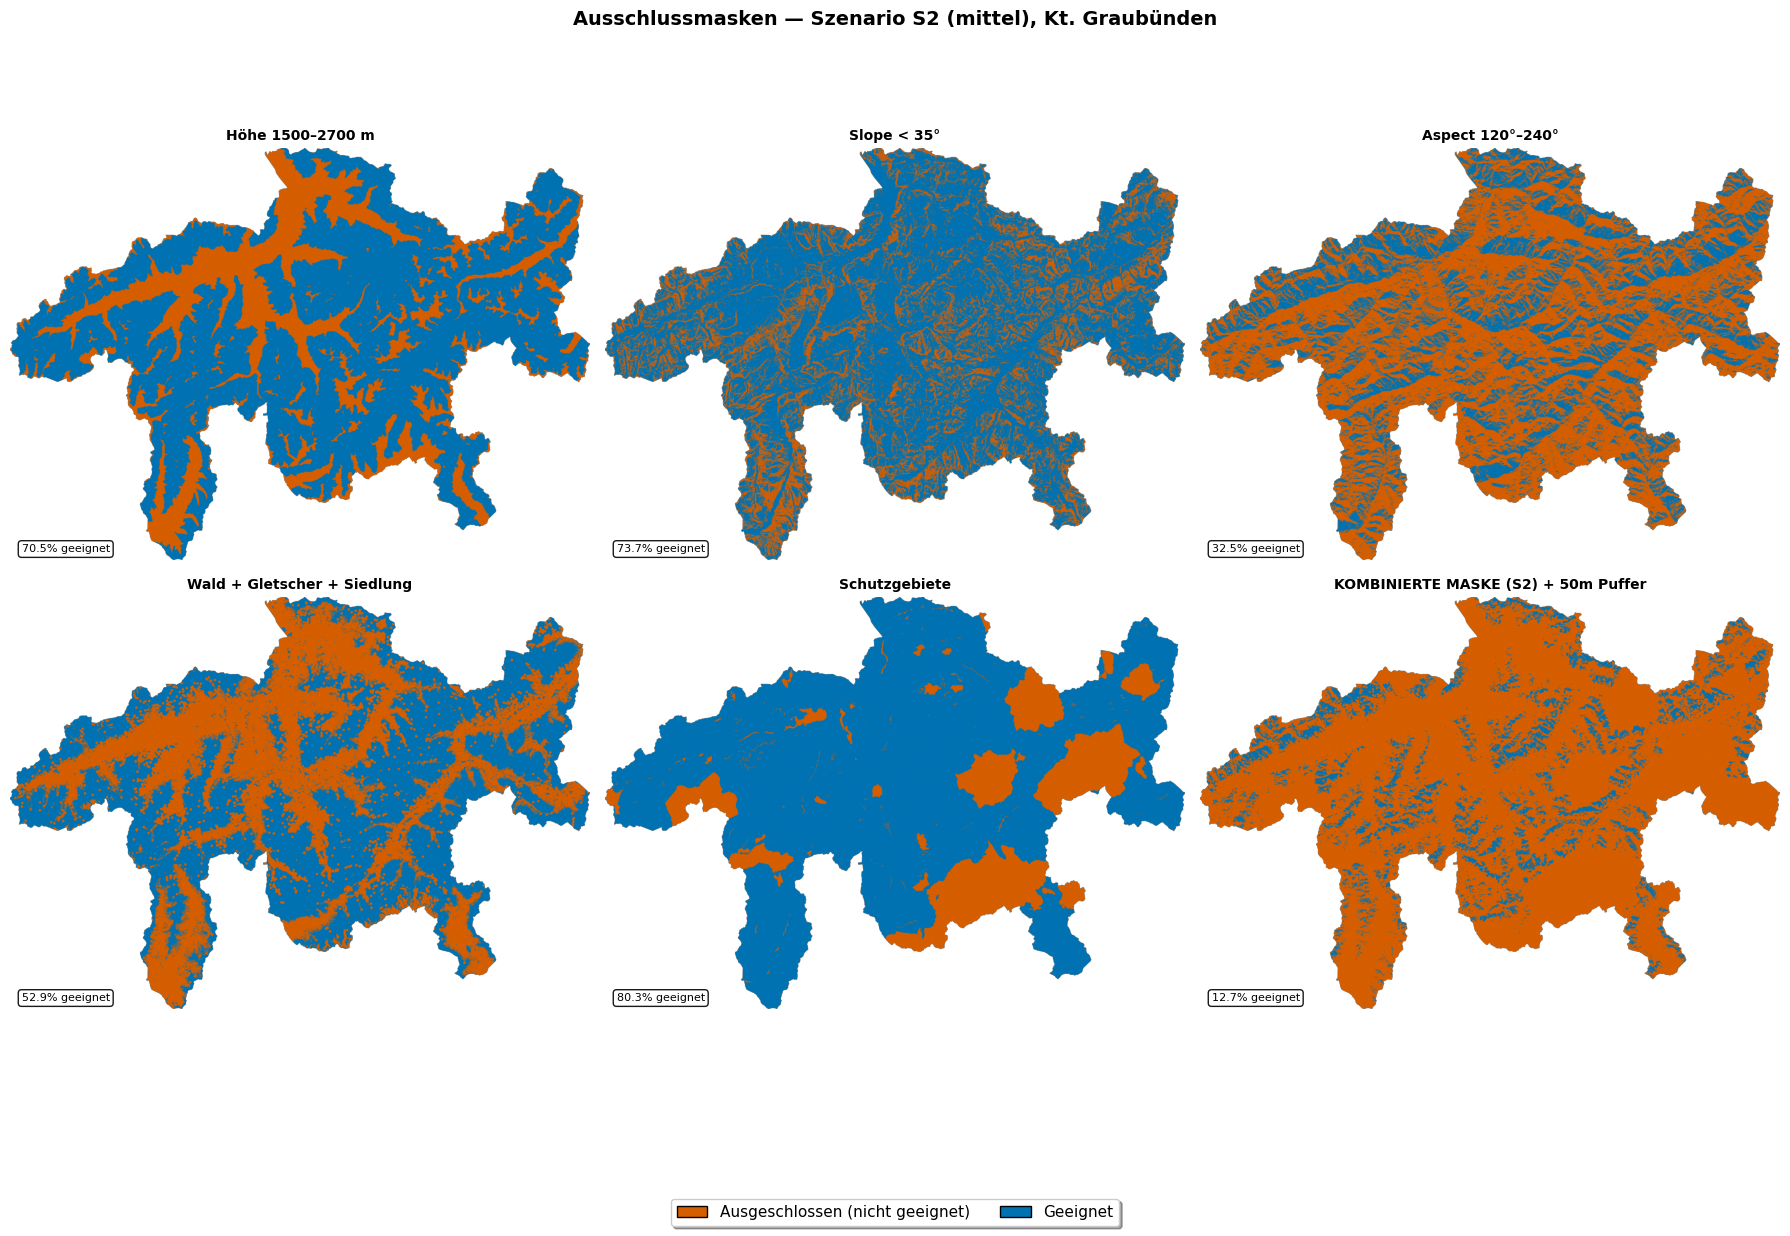

✓ 34.0s


In [ ]:
print("=== Visualisierung ===\n")
t0 = time.time()

# Lade gepufferte Maske falls nicht im Speicher
if 'combined_buffered' not in locals():
    print("  Lade gepufferte Maske...")
    with rasterio.open(PROC / "constraints/constraint_mask_s2_buffered50m.tif") as src:
        combined_buffered = src.read(1).astype(np.uint8)

# Farbenblindheit-freundliche Palette (Orange = ausgeschlossen, Blau = geeignet)
cmap_rg = LinearSegmentedColormap.from_list("cb_safe", ["#D55E00", "#0072B2"], N=256)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Ausschlussmasken — Szenario S2 (mittel), Kt. Graubünden", fontsize=14, fontweight="bold")

plot_masks = [
    (c01_elev_min & c02_elev_max, "Höhe 1500–2700 m"),
    (c03_slope, "Slope < 35°"),
    (c04_aspect, "Aspect 120°–240°"),
    (c13_wald & c15_gletscher & c20_siedlung, "Wald + Gletscher + Siedlung"),
    (c06_moorlandschaften & c07_biotope & c09_bln & c10_nationalpark, "Schutzgebiete"),
    (combined_buffered, "KOMBINIERTE MASKE (S2) + 50m Puffer"),
]

for ax, (data, title) in zip(axes.flat, plot_masks):
    masked = np.ma.masked_where(gr_mask_raster == 0, data.astype(float))
    ax.imshow(masked, cmap=cmap_rg, vmin=0, vmax=1, aspect="equal")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_axis_off()
    pct = data[gr_mask_raster == 1].sum() / total_px * 100
    ax.text(0.02, 0.02, f"{pct:.1f}% geeignet", transform=ax.transAxes,
            fontsize=8, bbox=dict(boxstyle="round", fc="white", alpha=0.9))

legend_elements = [
    Patch(facecolor='#D55E00', edgecolor='black', label='Ausgeschlossen (nicht geeignet)'),
    Patch(facecolor='#0072B2', edgecolor='black', label='Geeignet'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.04), frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
out_dir = Path("../outputs/figures")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "constraint_masks.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ {time.time() - t0:.1f}s")

## Nächster Schritt

Die kombinierte Ausschlussmaske liegt unter:

```
data/processed/constraints/constraint_mask_s2.tif
```

- Pixel = 1: Fläche ist potenziell geeignet (alle 20 Kriterien bestanden)
- Pixel = 0: Fläche ist ausgeschlossen (mindestens 1 Kriterium verletzt)

**→ Weiter mit:** Eignungsfaktoren berechnen (Normalisierung, Distanz-Raster, WLC-Inputs)